# Amazon E-Commerce Sales Analysis

## Project Objectice

The objectice of this project is to analyze Amazon E-Commerce sales data using python, SQL, MySQL, Power BI and Power Query to discover business insights and build interactive dashboards.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Power Query
- MySQL
- SQL
- Power BI
- Git & GitHub

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter 

print("libraries imported successfully..!")

libraries imported successfully..!


In [112]:
df = pd.read_csv("amazon_ecommerce_1M.csv")

print("data loaded successfully")

data loaded successfully


In [113]:
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


## Understanding the Dataset

In [114]:
print("Dataset Shape:", df.shape)
print(df.columns)

Dataset Shape: (1000000, 20)
Index(['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price',
       'discount', 'final_price', 'rating', 'review_count', 'stock',
       'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days',
       'location', 'device', 'payment_method', 'is_returned',
       'delivery_status'],
      dtype='object')


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

In [116]:
df.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13224.119093,28.996161,9938.876985,3.927226,32.626704,250.023345,3.750030,3.166389
std,18079.626921,14.681077,14271.885557,0.519443,43.382201,144.567038,0.722092,1.674178
min,200.030000,5.000000,101.460000,1.500000,0.000000,0.000000,2.500000,1.000000
25%,2700.147500,16.910000,1705.930000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4971.830000,28.070000,3790.795000,3.900000,20.000000,250.000000,3.800000,3.000000
75%,14134.482500,39.240000,10384.440000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,3408.000000,500.000000,5.000000,6.000000


In [117]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


## Data Inspection

In [118]:
missing_values = df.isnull().sum()
print(missing_values)

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64


In [119]:
missing_percentage = (df.isnull().sum() / len(df)) *100
print(missing_percentage)

user_id               0.0
product_id            0.0
category              0.0
subcategory           0.0
brand                 0.0
price                 0.0
discount              0.0
final_price           0.0
rating                0.0
review_count          0.0
stock                 0.0
seller_id             0.0
seller_rating         0.0
purchase_date         0.0
shipping_time_days    0.0
location              0.0
device                0.0
payment_method        0.0
is_returned           0.0
delivery_status       0.0
dtype: float64


In [120]:
df.dtypes

user_id                object
product_id             object
category               object
subcategory            object
brand                  object
price                 float64
discount              float64
final_price           float64
rating                float64
review_count            int64
stock                   int64
seller_id              object
seller_rating         float64
purchase_date          object
shipping_time_days      int64
location               object
device                 object
payment_method         object
is_returned              bool
delivery_status        object
dtype: object

## Data Cleaning

In [121]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

print("purchase_date converted successfully")

purchase_date converted successfully


In [122]:
df.dtypes

user_id                       object
product_id                    object
category                      object
subcategory                   object
brand                         object
price                        float64
discount                     float64
final_price                  float64
rating                       float64
review_count                   int64
stock                          int64
seller_id                     object
seller_rating                float64
purchase_date         datetime64[ns]
shipping_time_days             int64
location                      object
device                        object
payment_method                object
is_returned                     bool
delivery_status               object
dtype: object

## Exploratory Data Analysis

The objective of this section is to analyze the dataset, identify trends, understand customer purchasing behaviour, and generate business insights using python.

### 1. Dataset Overview

In [123]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nColumn Nmaes : ")
print(df.columns.tolist())

Number of Rows : 1000000
Number of Columns : 20

Column Nmaes : 
['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price', 'discount', 'final_price', 'rating', 'review_count', 'stock', 'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days', 'location', 'device', 'payment_method', 'is_returned', 'delivery_status']


### 2. Total Sales

In [124]:
total_sales = df["final_price"].sum()

print(f"Total Sales : Rs {total_sales:,.2f}")

Total Sales : Rs 9,938,876,984.90


### 3. Average Order Value

In [125]:
average_order = df["final_price"].mean()

print(f"Average Order Value : Rs {average_order:,.2f}")

Average Order Value : Rs 9,938.88


### 4. Top Product Categories

In [126]:
category_sales = (
    df.groupby("category")["final_price"]
    .sum()
    .sort_values(ascending = False))

print(category_sales)

category
Electronics    6.579048e+09
Home           1.529978e+09
Sports         1.124849e+09
Beauty         3.759517e+08
Clothing       3.290504e+08
Name: final_price, dtype: float64


### 5. Sales by Category

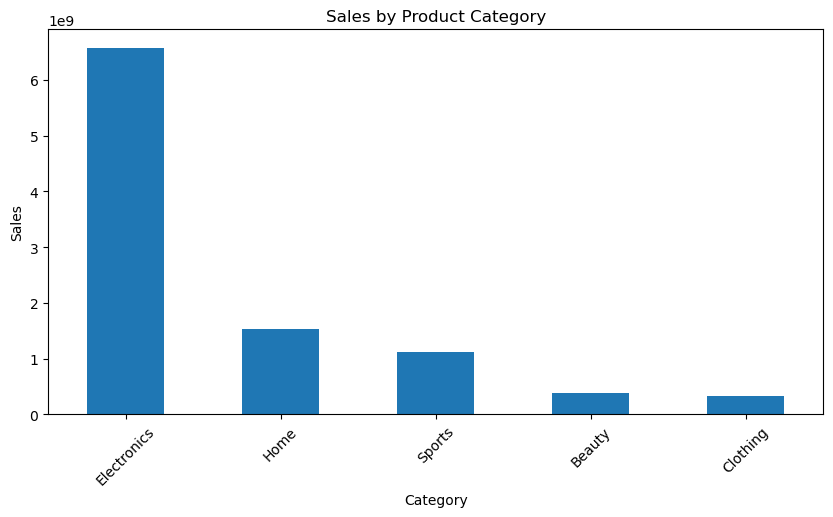

In [127]:
category_sales.plot(kind="bar", figsize=(10,5))

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

### 6. Top 10 Subcategories by Sales

In [128]:
subcategory_sales = (
    df.groupby("subcategory")["final_price"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

subcategory
Mobile        1.657298e+09
Laptop        1.652686e+09
Headphones    1.637538e+09
Camera        1.631526e+09
Decor         5.125229e+08
Kitchen       5.109966e+08
Furniture     5.064581e+08
Outdoor       3.769483e+08
Fitness       3.750556e+08
Cycling       3.728452e+08
Skincare      1.260788e+08
Haircare      1.250617e+08
Makeup        1.248112e+08
Kids          1.104925e+08
Men           1.097601e+08
Women         1.087979e+08
Name: final_price, dtype: float64


#### Visualization

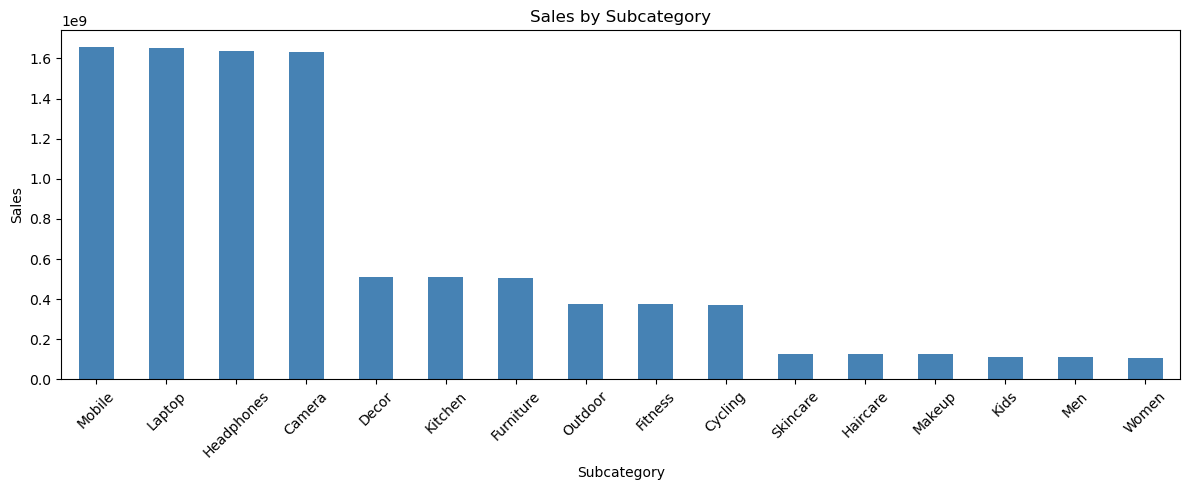

In [129]:
subcategory_sales.plot(kind="bar", figsize=(12,5), color = 'steelblue')

plt.title("Sales by Subcategory")
plt.xlabel("Subcategory")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- The highest-selling subcategory contributed the largest share of overall revenue, indicating strong customer demand.
- The top three subcategories account for a significant portion of total sales, suggesting these categories are key revenue drivers.
- Lower-performing subcategories may require promotional campaigns, pricing adjustments, or inventory optimization to improve sales.

### 7. Top Brands by Sales

In [130]:
brand_sales = (
    df.groupby("brand")["final_price"]
    .sum()
    .sort_values(ascending=False)
)

print(brand_sales)

brand
Lenovo     8.346983e+08
Sony       8.322272e+08
Samsung    8.315598e+08
LG         8.312689e+08
Adidas     8.280768e+08
Boat       8.277323e+08
HP         8.269937e+08
Nike       8.266456e+08
Zara       8.260282e+08
Apple      8.260040e+08
Puma       8.253044e+08
H&M        8.223380e+08
Name: final_price, dtype: float64


#### Visualization

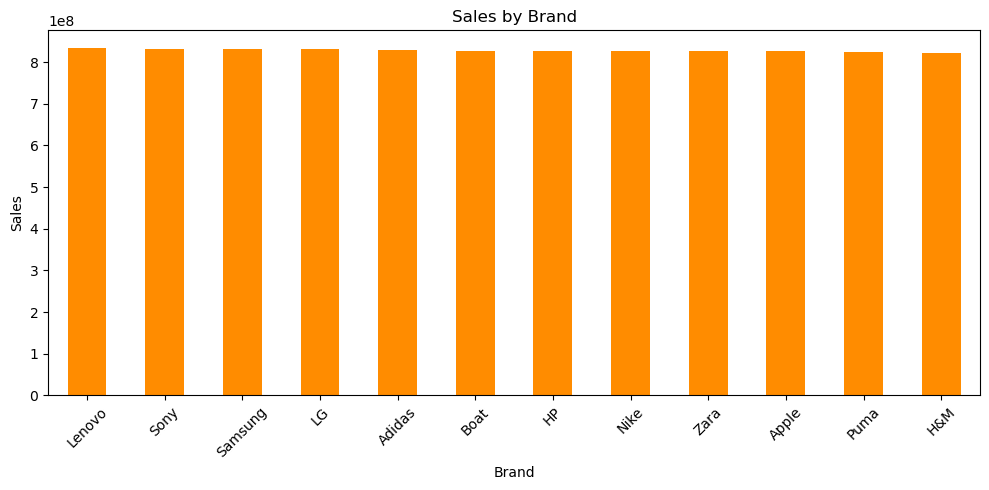

In [131]:
brand_sales.plot(kind="bar", figsize=(10,5), color='darkorange')

plt.title("Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

-A few leading brands dominate overall sales, demonstrating stronger customer trust and market preference.
- Brands with lower sales may benefit from improved product visibility, targeted marketing, or competitive pricing.
- Expanding partnerships with top-performing brands could further increase overall revenue.

### 8. Payment Method Distribution

In [132]:
payment_count = df["payment_method"].value_counts()

print(payment_count)

payment_method
Cash on Delivery    250388
Credit Card         250324
UPI                 249951
Debit Card          249337
Name: count, dtype: int64


#### Visualization

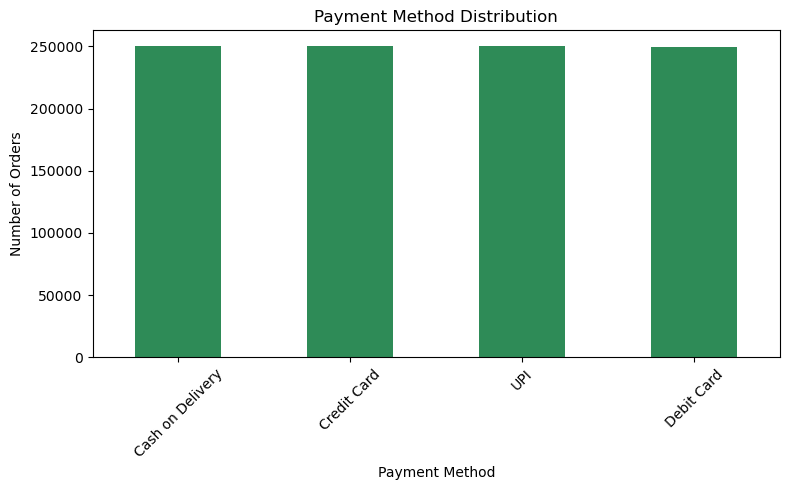

In [133]:
payment_count.plot(kind="bar", figsize=(8,5),color='seagreen')

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Customers show a clear preference for one payment method, indicating convenience and trust in that option.
- Maintaining reliable support for the most-used payment methods can enhance customer satisfaction and reduce checkout abandonment.
- Encouraging the use of less popular payment methods through cashback offers or discounts could diversify payment preferences.

### 9. Device Used for Purchases

In [134]:
device_count = df["device"].value_counts()

print(device_count)

device
Mobile App    333637
Web           333297
Tablet        333066
Name: count, dtype: int64


#### visualization

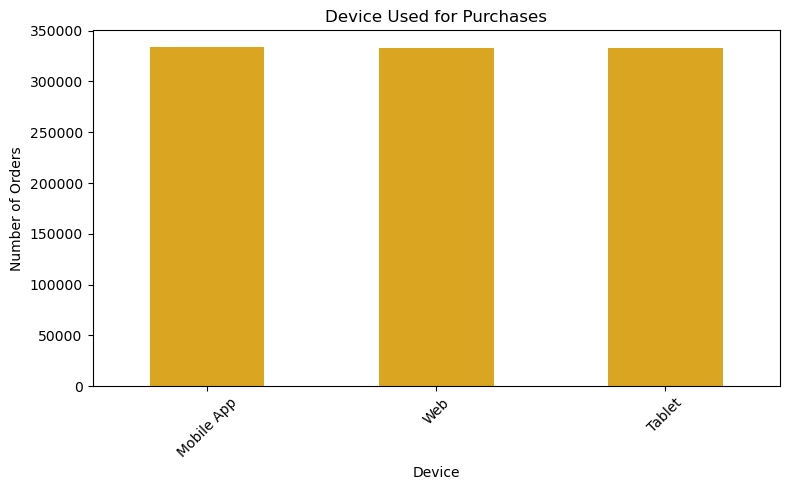

In [135]:
device_count.plot(kind="bar", figsize=(8,5), color='goldenrod')

plt.title("Device Used for Purchases")
plt.xlabel("Device")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- The majority of customers place orders using the most frequently used device, highlighting the importance of optimizing the shopping experience for that platform.
- Ensuring responsive design and fast page performance on the preferred device can improve conversion rates.
- Marketing strategies should prioritize the platform with the highest customer engagement.

### 10. Delivery Status Analysis

In [136]:
delivery_status = df["delivery_status"].value_counts()

print(delivery_status)

delivery_status
Delivered     295234
Delayed       294983
In Transit    293793
Returned      115990
Name: count, dtype: int64


#### Visualization

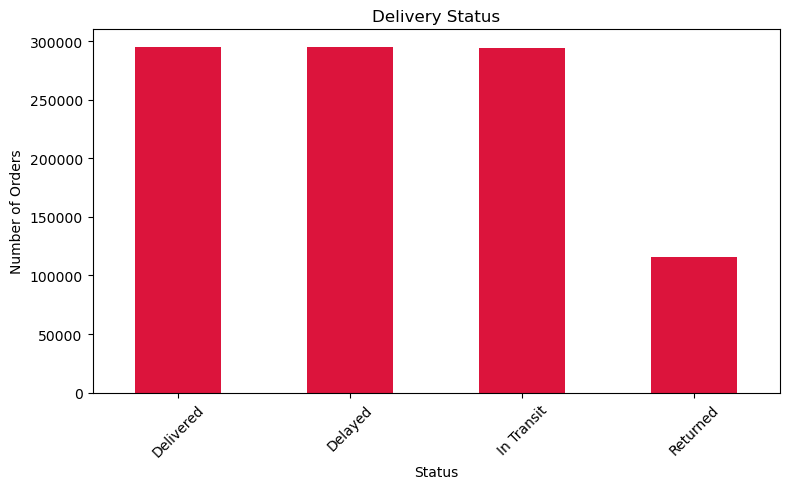

In [137]:
delivery_status.plot(kind="bar", figsize=(8,5), color='crimson')

plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Most orders were delivered successfully, reflecting an efficient order fulfillment process.
- Orders with delayed, cancelled, or returned statuses should be monitored to identify operational bottlenecks.
- Improving logistics, inventory management, and courier coordination can further enhance customer satisfaction and delivery performance.

### 11. Monthly Sales Trend

In [138]:
df['Month'] = df['purchase_date'].dt.to_period('M').astype(str)

monthly_sales = (df.groupby('Month')['final_price'].sum().sort_index())

print(monthly_sales)

Month
2024-03    1.388802e+07
2024-04    4.096292e+08
2024-05    4.207856e+08
2024-06    4.051715e+08
2024-07    4.217882e+08
2024-08    4.202220e+08
2024-09    4.039997e+08
2024-10    4.235672e+08
2024-11    4.118936e+08
2024-12    4.220663e+08
2025-01    4.247258e+08
2025-02    3.787897e+08
2025-03    4.230896e+08
2025-04    4.033051e+08
2025-05    4.200312e+08
2025-06    4.056538e+08
2025-07    4.213890e+08
2025-08    4.265546e+08
2025-09    3.999008e+08
2025-10    4.222367e+08
2025-11    4.056734e+08
2025-12    4.281423e+08
2026-01    4.214767e+08
2026-02    3.812453e+08
2026-03    4.236515e+08
Name: final_price, dtype: float64


#### Visualization

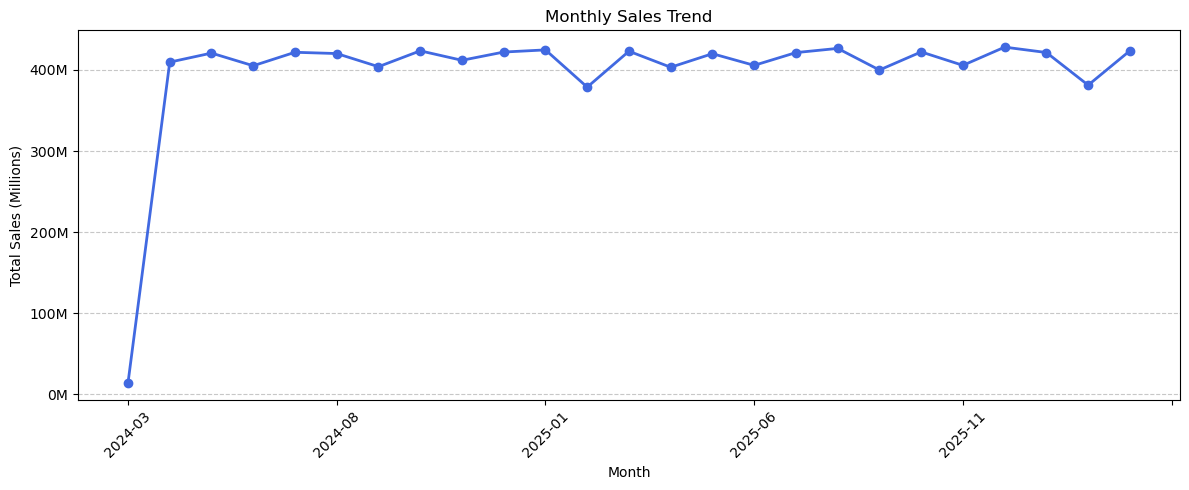

In [139]:
monthly_sales.plot(kind='line',figsize=(12,5),marker='o',linewidth=2,color='royalblue')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Business Insights:

- Monthly sales remained relatively stable after April 2024, indicating consistent customer demand throughout the observed period.
- March 2024 recorded significantly lower sales, suggesting incomplete monthly data or reduced business activity during that period.
- The absence of major fluctuations indicates steady revenue performance, which supports predictable inventory planning and operational decision-making.

### 12. Customer Ratings Analysis

In [140]:
average_rating = df['rating'].mean()
print(f"Average Customer Rating : {average_rating:.2f}")

rating_distribution = df['rating'].value_counts().sort_index()
print(rating_distribution)

Average Customer Rating : 3.93
rating
1.5        1
1.6        5
1.7        8
1.8        8
1.9       29
2.0       71
2.1      121
2.2      296
2.3      555
2.4      979
2.5     1669
2.6     2930
2.7     4870
2.8     7412
2.9    11171
3.0    15888
3.1    22188
3.2    29118
3.3    37514
3.4    46680
3.5    55499
3.6    62998
3.7    69282
3.8    73536
3.9    76085
4.0    74253
4.1    70828
4.2    64950
4.3    57378
4.4    49801
4.5    40985
4.6    33011
4.7    25664
4.8    19481
4.9    14517
5.0    30219
Name: count, dtype: int64


#### Visualization

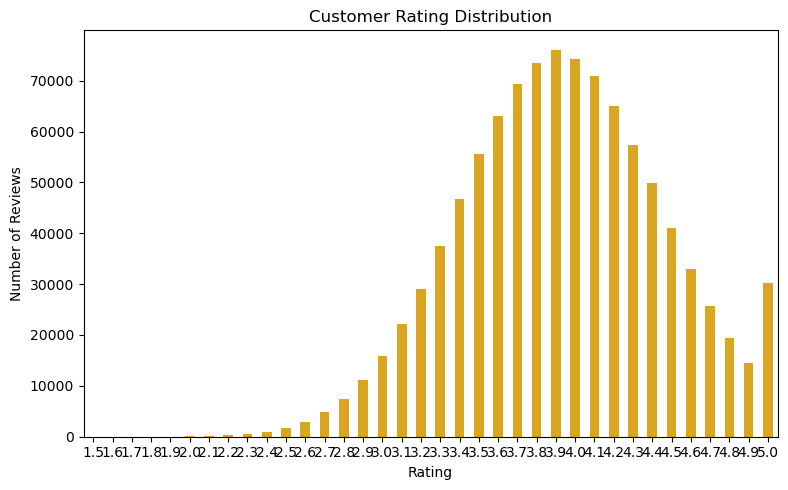

In [141]:
rating_distribution.plot(kind='bar',figsize=(8,5),color='goldenrod')

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights:

- The average customer rating provides an overall measure of customer satisfaction.
- Higher frequencies of 4-star and 5-star ratings indicate strong customer experience and product quality.
- Lower ratings highlight opportunities to improve product quality, delivery service, or customer support.

### Average Rating by Category

In [142]:
category_rating = (
    df.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

category
Electronics    4.206092
Home           3.902324
Sports         3.876259
Clothing       3.826767
Beauty         3.824287
Name: rating, dtype: float64


#### Visualization

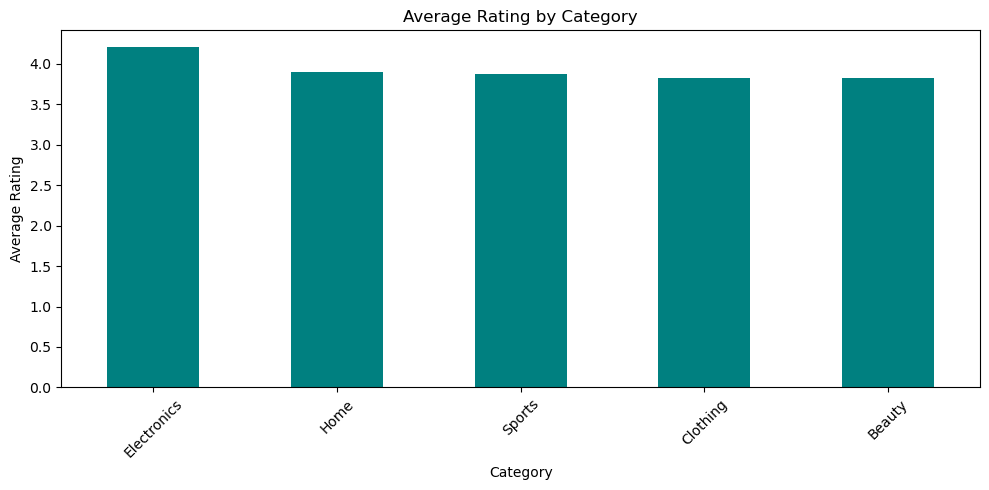

In [143]:
category_rating.plot(kind='bar',figsize=(10,5),color='teal')

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Categories with higher average ratings demonstrate greater customer satisfaction and stronger product performance.
- Categories with lower ratings may require quality improvements, better product descriptions, or enhanced customer support.
- Understanding customer ratings across categories helps prioritize improvements and maintain customer loyalty.

### 13. Return Analysis

In [144]:
return_count = df['is_returned'].value_counts()

print(return_count)

is_returned
False    884010
True     115990
Name: count, dtype: int64


#### Visualization

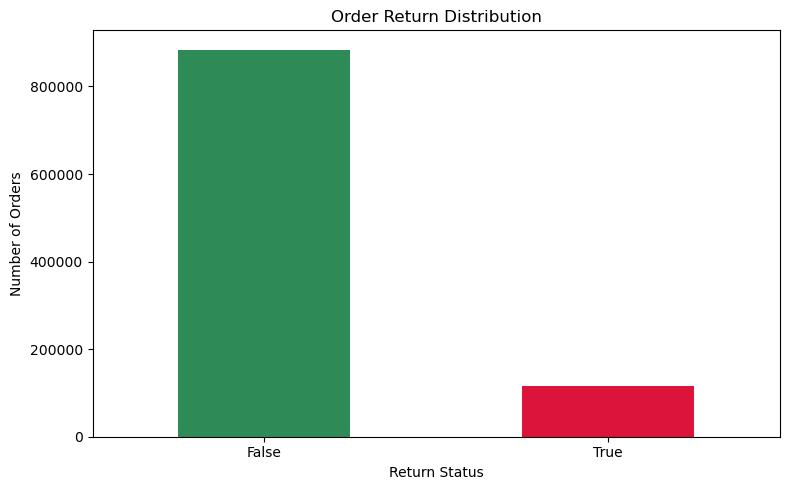

In [145]:
return_count.plot(kind='bar',figsize=(8,5),color=['seagreen', 'crimson'])

plt.title("Order Return Distribution")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insights:

- The majority of orders were successfully retained, indicating strong customer satisfaction and product acceptance.
- Returned orders represent potential revenue loss and increased operational costs.
- Monitoring return patterns helps improve product quality, customer experience, and profitability.

#### Return Percentage and Returns by Category

In [146]:
return_percentage = (
    df['is_returned']
    .value_counts(normalize=True) * 100
)

print(return_percentage.round(2))


category_returns = (
    df.groupby('category')['is_returned']
    .sum()
    .sort_values(ascending=False)
)

print(category_returns)

is_returned
False    88.4
True     11.6
Name: proportion, dtype: float64
category
Clothing       23452
Beauty         23433
Sports         23279
Home           23275
Electronics    22551
Name: is_returned, dtype: int64


#### Visualization

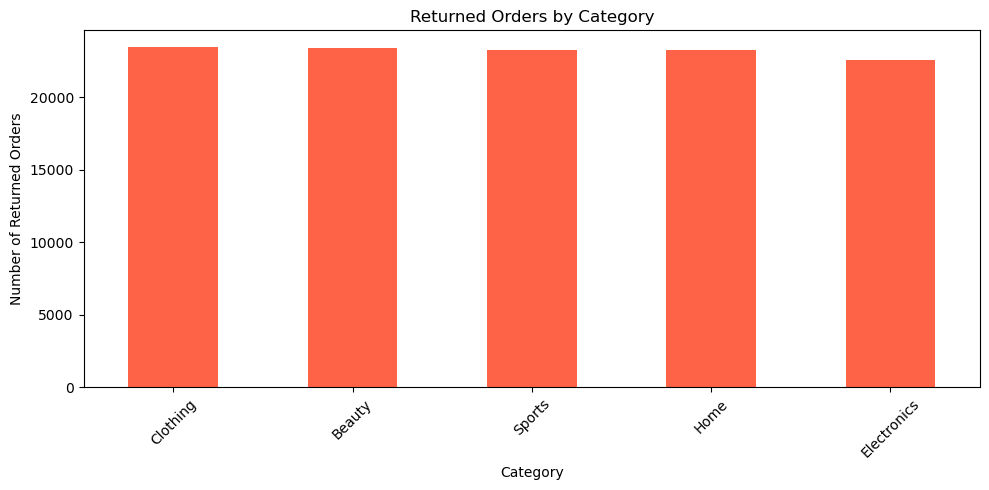

In [147]:
category_returns.plot(kind='bar',figsize=(10,5),color='tomato')

plt.title("Returned Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Returned Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Categories with the highest number of returned products should be investigated for quality issues or customer expectations.
- Reducing returns in high-return categories can significantly improve profitability.
- Product descriptions, sizing information, and quality checks can help lower return rates.

### 14. Shipping Time Analysis

In [148]:
# Average Sipping Time
average_shipping = df['shipping_time_days'].mean()

print(f"Average Shipping Time: {average_shipping:.2f} days")

Average Shipping Time: 3.17 days


In [149]:
# Shipping TIme Distribution
shipping_distribution = df['shipping_time_days'].value_counts().sort_index()

print(shipping_distribution)

shipping_time_days
1    232944
2    167372
3    166095
4    167347
5    166424
6     99818
Name: count, dtype: int64


#### Visualization

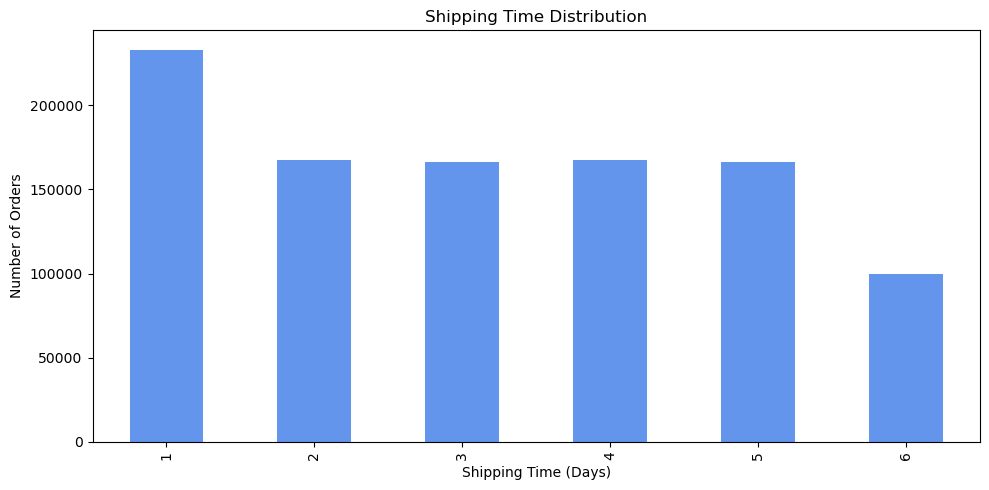

In [150]:
shipping_distribution.plot(kind='bar',figsize=(10,5),color='cornflowerblue')

plt.title("Shipping Time Distribution")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Business Insights:

- Most orders were delivered within the common shipping time range, indicating an efficient delivery process.
- Extremely long shipping times may negatively affect customer satisfaction and increase return rates.
- Monitoring shipping performance helps improve logistics planning and delivery reliability.

#### Average Shipping Time By Delivery Status

In [151]:
shipping_status = (
    df.groupby('delivery_status')['shipping_time_days']
    .mean()
    .sort_values(ascending=False)
)

print(shipping_status)

delivery_status
Returned      3.409690
Delayed       3.140581
Delivered     3.131574
In Transit    3.131232
Name: shipping_time_days, dtype: float64


#### Visualization

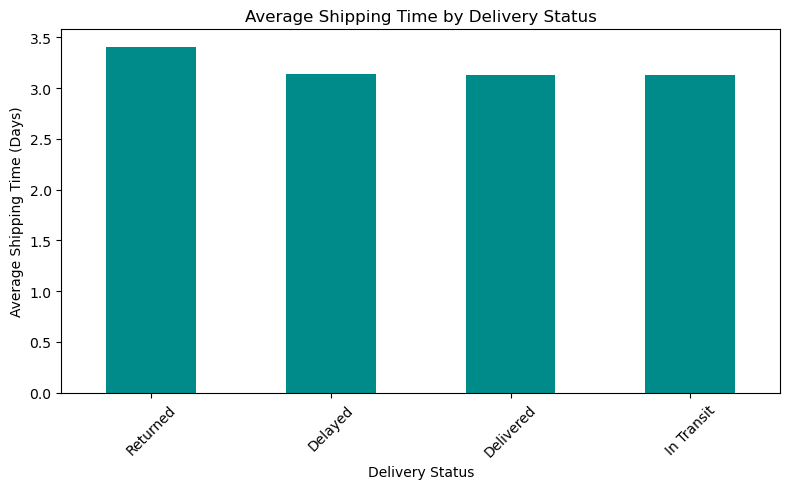

In [152]:
shipping_status.plot(kind='bar',figsize=(8,5),color='darkcyan')

plt.title("Average Shipping Time by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Shipping Time (Days)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Delivered orders generally have predictable shipping times, reflecting operational consistency.
- Orders with delayed or failed delivery statuses may require longer shipping durations due to logistics challenges.
- Improving shipping efficiency can enhance customer satisfaction and reduce delivery-related complaints.

### 15. Seller Performance Analysis

In [153]:
seller_revenue = (
    df.groupby('seller_id')['final_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(seller_revenue)

seller_id
S7740    1891954.53
S2013    1810498.08
S4656    1791917.86
S6442    1786697.11
S2478    1776687.77
S6505    1765031.94
S9944    1757840.15
S4105    1749599.85
S3684    1746322.26
S5719    1744748.24
Name: final_price, dtype: float64


#### Visualization

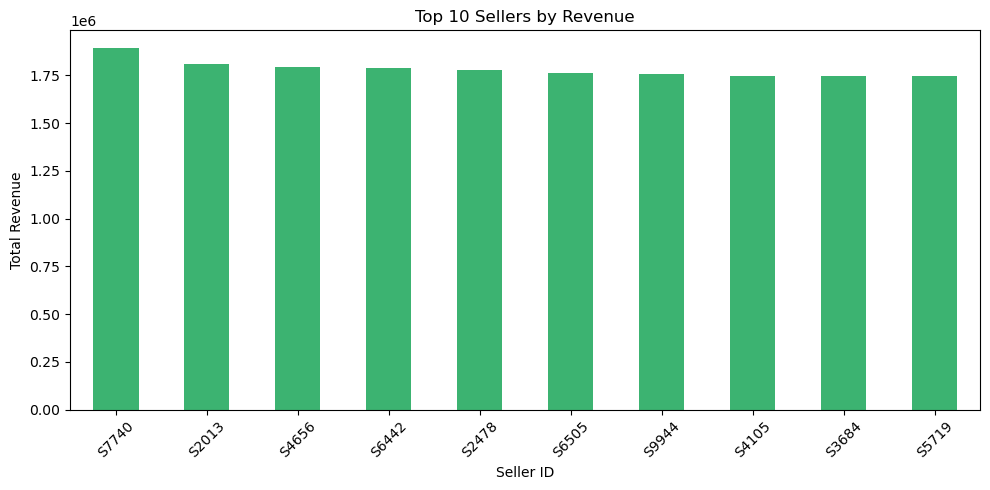

In [154]:
seller_revenue.plot(kind='bar',figsize=(10,5),color='mediumseagreen')

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- A small group of sellers contributes a significant portion of total revenue.
- High-performing sellers can be rewarded through loyalty programs or exclusive incentives.
- Lower-performing sellers may benefit from training, marketing support, or improved product visibility.

#### Average Seller Rating

In [155]:
seller_rating = (
    df.groupby('seller_id')['seller_rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(seller_rating)

seller_id
S8479    3.984252
S5012    3.982609
S5225    3.982000
S2699    3.980435
S3584    3.979381
S9061    3.978899
S6219    3.974257
S7583    3.972727
S1635    3.972477
S6764    3.966071
Name: seller_rating, dtype: float64


#### Visualization

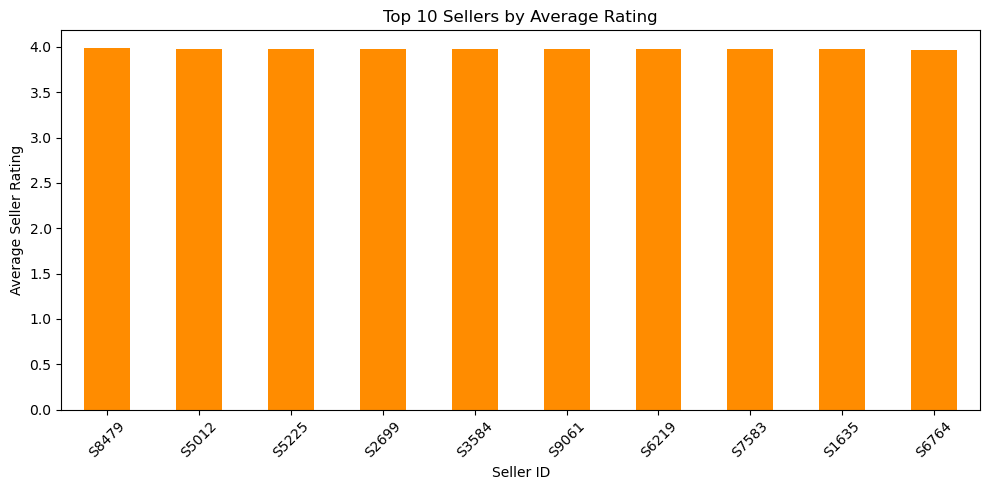

In [156]:
seller_rating.plot(kind='bar',figsize=(10,5),color='darkorange')

plt.title("Top 10 Sellers by Average Rating")
plt.xlabel("Seller ID")
plt.ylabel("Average Seller Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Sellers with consistently high ratings demonstrate strong customer satisfaction and service quality.
- Monitoring seller ratings helps maintain marketplace standards and customer trust.
- Encouraging best practices from top-rated sellers can improve the overall customer experience.

### 16. Location-Wise Sales Analysis

In [157]:
location_sales = (
    df.groupby('location')['final_price']
    .sum()
    .sort_values(ascending=False)
)

print(location_sales)

location
Delhi        2.000521e+09
Bangalore    1.990174e+09
Mumbai       1.988988e+09
Chennai      1.981130e+09
Hyderabad    1.978064e+09
Name: final_price, dtype: float64


#### Visualization

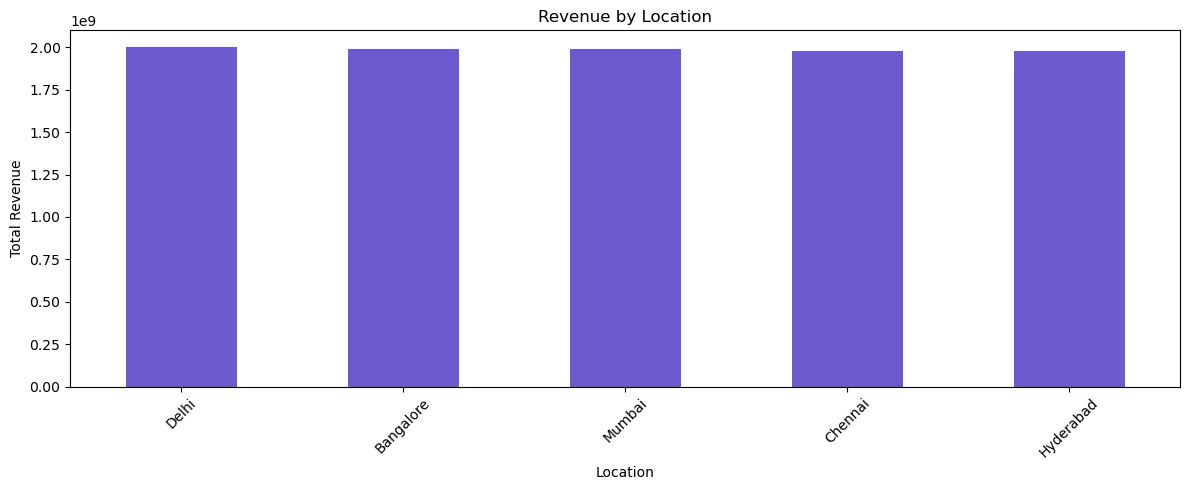

In [158]:
location_sales.plot(kind='bar',figsize=(12,5),color='slateblue')

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- Some locations contribute significantly more revenue than others, indicating stronger customer demand.
- High-performing locations should be prioritized for inventory allocation, marketing campaigns, and customer engagement initiatives.
- Lower-performing locations present opportunities for localized promotions and targeted business strategies to increase sales.

#### Top 10 Locations by Revenue

In [159]:
top_locations = (
    df.groupby('location')['final_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_locations)

location
Delhi        2.000521e+09
Bangalore    1.990174e+09
Mumbai       1.988988e+09
Chennai      1.981130e+09
Hyderabad    1.978064e+09
Name: final_price, dtype: float64


#### Visualization

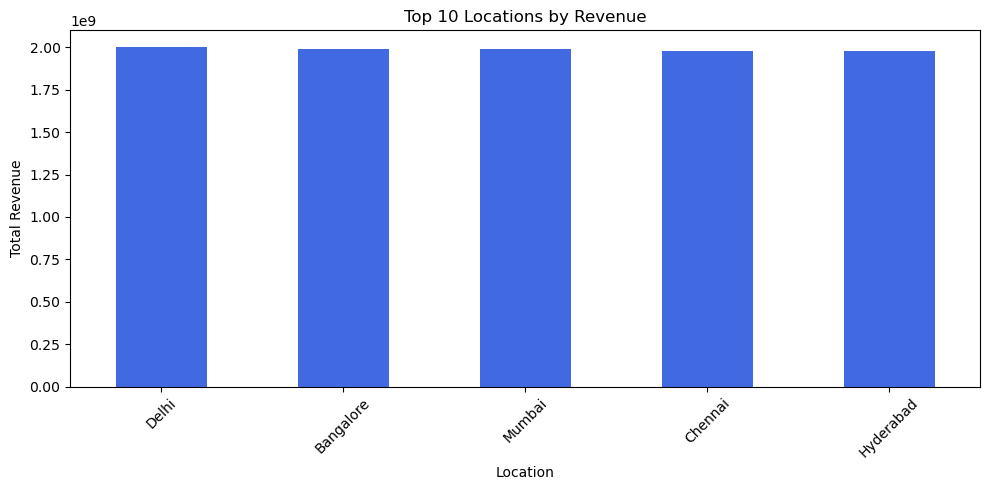

In [160]:
top_locations.plot(kind='bar',figsize=(10,5),color='royalblue')

plt.title("Top 10 Locations by Revenue")
plt.xlabel("Location")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insights:

- The top-performing locations contribute a substantial share of overall revenue.
- Focusing marketing efforts and maintaining sufficient inventory in these regions can maximize business growth.
- Analyzing customer preferences in these locations can help replicate success in other markets.